In [35]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [36]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
print(words[:8])


32033
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [37]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s: i + 1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [38]:
block_size = 3 # context length: how many characters do we take to predict the next one
# build the dataset
def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])  # 80%
Xdev, Ydev = build_dataset(words[n1:n2])  # 10%
Xte, Yte = build_dataset(words[n2:])  # 10%


In [39]:
for x,y in zip(Xtr[:20], Ytr[:20]):
    print("".join(itos[i.item()] for i in x), "->", itos[y.item()])

... -> y
..y -> u
.yu -> h
yuh -> e
uhe -> n
hen -> g
eng -> .
... -> d
..d -> i
.di -> o
dio -> n
ion -> d
ond -> r
ndr -> e
dre -> .
... -> x
..x -> a
.xa -> v
xav -> i
avi -> e


In [40]:
class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_out, fan_in)) / fan_in ** 0.5
        self.bias = torch.zeros(fan_out) if bias else None
        
    def __call__(self, x):
        self.out = x @ self.weight.T
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])
    
class BatchNorm1d:
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # parameters (trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers (trained with a running `momentum update`)
        # exponential moving average
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)
    
    def __call__(self, x):
        # calculate the forward pass
        if self.training:
            xmean = x.mean(0, keepdim=True) # batch mean
            xvar = x.var(0, keepdim=True) # batch variance
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
        self.out = self.gamma * xhat + self.beta # scale and shift
        # update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]
    
    def buffers(self):
        return [self.running_mean, self.running_var]

class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    
    def parameters(self):
        return []

In [41]:
torch.manual_seed(42) # seed rng for reproducibility

In [51]:
n_embd = 10 # the dimension of the embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of MLP

C = torch.randn((vocab_size, n_embd))
layers = [
    Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size)
]

# parameters init
with torch.no_grad():
    layers[-1].weight *= 0.1 # last year make less confident

parameters = [C] + [p for l in layers for p in l.parameters()]
print(sum(p.numel() for p in parameters)) # number of parameters in total
for p in parameters:
    p.requires_grad = True


12097


      0/ 200000 3.2850
   1000/ 200000 2.0886
   2000/ 200000 2.5894
   3000/ 200000 2.5660
   4000/ 200000 2.6268
   5000/ 200000 2.8081
   6000/ 200000 2.7673
   7000/ 200000 2.4159
   8000/ 200000 2.2977
   9000/ 200000 2.4034
  10000/ 200000 2.4558
  11000/ 200000 2.4497
  12000/ 200000 2.1047
  13000/ 200000 2.2793
  14000/ 200000 2.1302
  15000/ 200000 2.3208
  16000/ 200000 2.0343
  17000/ 200000 2.3353
  18000/ 200000 2.3154
  19000/ 200000 1.9315
  20000/ 200000 2.3071
  21000/ 200000 2.1492
  22000/ 200000 2.0582
  23000/ 200000 2.4429
  24000/ 200000 2.0789
  25000/ 200000 1.8958
  26000/ 200000 1.8755
  27000/ 200000 2.0918
  28000/ 200000 2.1212
  29000/ 200000 2.5740
  30000/ 200000 2.0616
  31000/ 200000 2.1116
  32000/ 200000 2.0733
  33000/ 200000 2.1536
  34000/ 200000 2.0229
  35000/ 200000 2.1095
  36000/ 200000 2.3706
  37000/ 200000 2.4022
  38000/ 200000 2.3137
  39000/ 200000 1.8169
  40000/ 200000 1.9157
  41000/ 200000 2.2825
  42000/ 200000 2.3579
  43000/ 20

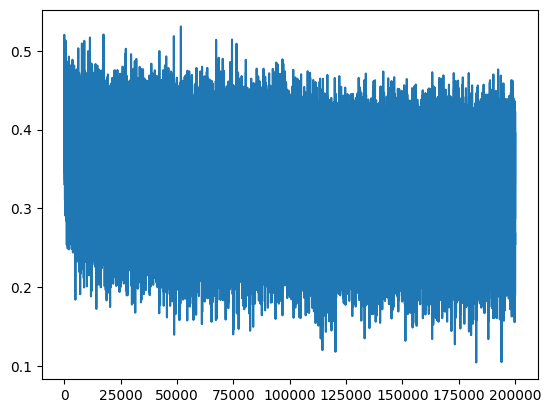

In [52]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]
    # forward pass
    emb = C[Xb] # embed the characters into vectors
    x = emb.view(emb.shape[0], -1) # flatten the batch of embeddings
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb)
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data -= lr * p.grad
    # exponential moving average of the loss
    lossi.append(loss.log10().item())

    # track stats
    if i % 1000 == 0:
        print(f"{i:7d}/{max_steps:7d} {loss.item():.4f}")

# plot the loss
plt.plot(lossi)
        

In [53]:
# put layers into eval mode (needed for batchnorm especially)
for layer in layers:
    layer.training = False

In [54]:
# evaluate the loss
@torch.no_grad()  # this decorator disables gradient tracking inside pytorch
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    emb = C[x] # (N, block_size, n_embd)
    x = emb.view(emb.shape[0], -1) # (N, block_size * n_embd)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, y)
    print(f"{split}: {loss.item():.4f}")

split_loss('train')
split_loss('val')

train: 2.0642
val: 2.1068


In [55]:
# sample from the model
for _ in range(20):
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
        # forward pass the neural next
        emb = C[torch.tensor([context])] # (1, block_size, n_embd)
        x = emb.view(emb.shape[0], -1) # concatenate the vectors
        for layer in layers:
            x = layer(x)
        logits = x
        probs = F.softmax(logits, dim=-1)
        # sample from the distribution
        ix = torch.multinomial(probs, num_samples=1).item()
        # update the context
        context = context[1:] + [ix]
        # shift the context window and track the samples
        context = context[1:] + [ix]
        out.append(itos[ix])
        # break if we hit a ... or EOS token
        if ix == 0:
            break
    print("".join(out))
        
        

gergiglyani.
sacalenele.
canelani.
mecanadutafaraziaculene.
si.
aiobarigi.
cozori.
seyanadyanarie.
xasahananasemyam.
sa.
erle.
qiane.
ari.
joly.
nuc.
guliracorisayianane.
kli.
ami.
nele.
pene.


# Step1 fix the plt.plot(lossi)

In [56]:
print(torch.arange(10).view(2, 5))
print(torch.tensor(lossi).view(-1, 1000).shape)
print(torch.tensor(lossi).view(-1,1000).mean(1).shape)


tensor([[0, 1, 2, 3, 4],
        [5, 6, 7, 8, 9]])
torch.Size([200, 1000])
torch.Size([200])


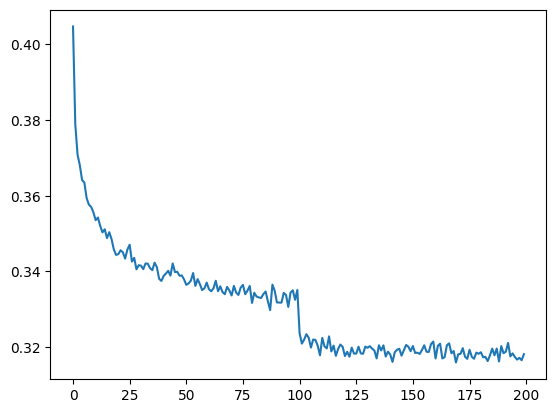

In [57]:
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))

# Step 2 Fixing layers
- make layers to incorperate `C = torch.randn((vocab_size, n_embd))`
- make layers to incorperate `emb = C[Xb]; x = emb.view(emb.shape[0], -1)`

In [58]:
class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_out, fan_in)) / fan_in ** 0.5
        self.bias = torch.zeros(fan_out) if bias else None
        
    def __call__(self, x):
        self.out = x @ self.weight.T
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])
    
class BatchNorm1d:
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # parameters (trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers (trained with a running `momentum update`)
        # exponential moving average
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)
    
    def __call__(self, x):
        # calculate the forward pass
        if self.training:
            xmean = x.mean(0, keepdim=True) # batch mean
            xvar = x.var(0, keepdim=True) # batch variance
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
        self.out = self.gamma * xhat + self.beta # scale and shift
        # update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]
    
    def buffers(self):
        return [self.running_mean, self.running_var]

class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    
    def parameters(self):
        return []

#--------------------------------
class Embedding:
    def __init__(self, num_embeddings, embedding_dim):
        self.weight = torch.randn((num_embeddings, embedding_dim))
        
    def __call__(self, IX):
        return self.weight[IX]
    
    def parameters(self):
        return [self.weight]
    
#--------------------------------
class Flatten:
    def __call__(self, x):
        self.out = x.view(x.shape[0], -1)
        return self.out
    
    def parameters(self):
        return []



In [60]:
n_embd = 10 # the dimension of the embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of MLP

# C = torch.randn((vocab_size, n_embd))
layers = [
    Embedding(vocab_size, n_embd),
    Flatten(),
    Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size)
]

# parameters init
with torch.no_grad():
    layers[-1].weight *= 0.1 # last year make less confident

parameters = [p for l in layers for p in l.parameters()]
print(sum(p.numel() for p in parameters)) # number of parameters in total
for p in parameters:
    p.requires_grad = True


12097


      0/ 200000 3.2908
   1000/ 200000 2.1040
   2000/ 200000 2.3234
   3000/ 200000 1.7719
   4000/ 200000 2.4453
   5000/ 200000 2.6836
   6000/ 200000 2.3703
   7000/ 200000 2.2705
   8000/ 200000 2.1244
   9000/ 200000 2.5203
  10000/ 200000 2.1646
  11000/ 200000 2.3909
  12000/ 200000 2.4200
  13000/ 200000 2.5904
  14000/ 200000 2.7345
  15000/ 200000 1.9975
  16000/ 200000 2.0680
  17000/ 200000 2.5452
  18000/ 200000 1.9594
  19000/ 200000 2.2379
  20000/ 200000 2.5483
  21000/ 200000 2.2329
  22000/ 200000 2.6545
  23000/ 200000 1.8295
  24000/ 200000 2.1325
  25000/ 200000 2.2433
  26000/ 200000 2.5001
  27000/ 200000 2.1128
  28000/ 200000 2.5734
  29000/ 200000 2.6139
  30000/ 200000 1.9272
  31000/ 200000 2.4009
  32000/ 200000 2.2864
  33000/ 200000 2.1685
  34000/ 200000 1.9740
  35000/ 200000 2.4148
  36000/ 200000 2.2702
  37000/ 200000 2.3675
  38000/ 200000 2.6011
  39000/ 200000 2.3349
  40000/ 200000 2.0900
  41000/ 200000 2.1287
  42000/ 200000 1.8799
  43000/ 20

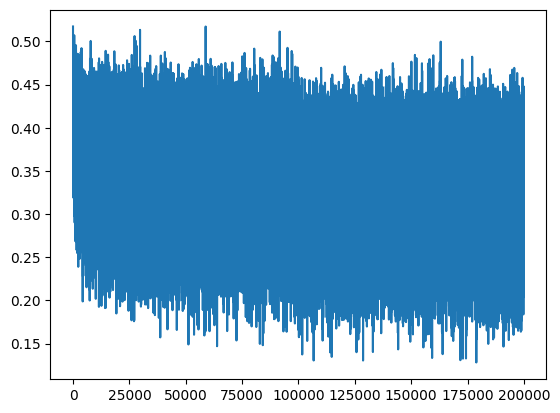

In [ ]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]
    # forward pass
    # emb = C[Xb] # embed the characters into vectors
    # x = emb.view(emb.shape[0], -1) # flatten the batch of embeddings
    x = Xb
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb)
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data -= lr * p.grad
    # exponential moving average of the loss
    lossi.append(loss.log10().item())

    # track stats
    if i % 1000 == 0:
        print(f"{i:7d}/{max_steps:7d} {loss.item():.4f}")

# plot the loss
plt.plot(lossi)
        

# Step 3 Create Containers

In [72]:
class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_out, fan_in)) / fan_in ** 0.5
        self.bias = torch.zeros(fan_out) if bias else None
        
    def __call__(self, x):
        self.out = x @ self.weight.T
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])
    
class BatchNorm1d:
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # parameters (trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers (trained with a running `momentum update`)
        # exponential moving average
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)
    
    def __call__(self, x):
        # calculate the forward pass
        if self.training:
            xmean = x.mean(0, keepdim=True) # batch mean
            xvar = x.var(0, keepdim=True) # batch variance
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
        self.out = self.gamma * xhat + self.beta # scale and shift
        # update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]
    
    def buffers(self):
        return [self.running_mean, self.running_var]

class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    
    def parameters(self):
        return []

#--------------------------------
class Embedding:
    def __init__(self, num_embeddings, embedding_dim):
        self.weight = torch.randn((num_embeddings, embedding_dim))
        
    def __call__(self, IX):
        return self.weight[IX]
    
    def parameters(self):
        return [self.weight]
    
#--------------------------------
class Flatten:
    def __call__(self, x):
        self.out = x.view(x.shape[0], -1)
        return self.out
    
    def parameters(self):
        return []


#--------------------------------
class Sequential:
    def __init__(self, layers):
        self.layers = layers
        
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out
    
    def parameters(self):
        return [p for l in self.layers for p in l.parameters()]
        

In [73]:
n_embd = 10 # the dimension of the embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of MLP

# C = torch.randn((vocab_size, n_embd))
model = Sequential([
    Embedding(vocab_size, n_embd),
    Flatten(),
    Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size)
])

# parameters init
with torch.no_grad():
    layers[-1].weight *= 0.1 # last year make less confident

parameters = model.parameters()
print(sum(p.numel() for p in parameters)) # number of parameters in total
for p in parameters:
    p.requires_grad = True


12097


      0/ 200000 3.5183
   1000/ 200000 2.0200
   2000/ 200000 2.2513
   3000/ 200000 2.6796
   4000/ 200000 2.1925
   5000/ 200000 2.2487
   6000/ 200000 2.3712
   7000/ 200000 2.3564
   8000/ 200000 2.2104
   9000/ 200000 2.6904
  10000/ 200000 1.8968
  11000/ 200000 2.2445
  12000/ 200000 2.3742
  13000/ 200000 2.0311
  14000/ 200000 2.0143
  15000/ 200000 2.3195
  16000/ 200000 2.7126
  17000/ 200000 2.2136
  18000/ 200000 2.0019
  19000/ 200000 1.9232
  20000/ 200000 2.0931
  21000/ 200000 2.0783
  22000/ 200000 2.1392
  23000/ 200000 2.1022
  24000/ 200000 2.1041
  25000/ 200000 2.0648
  26000/ 200000 2.0657
  27000/ 200000 2.3832
  28000/ 200000 2.0553
  29000/ 200000 2.2961
  30000/ 200000 2.3930
  31000/ 200000 2.4630
  32000/ 200000 2.3820
  33000/ 200000 2.1053
  34000/ 200000 2.2518
  35000/ 200000 1.9744
  36000/ 200000 1.9927
  37000/ 200000 2.1434
  38000/ 200000 2.4877
  39000/ 200000 1.8966
  40000/ 200000 2.0778
  41000/ 200000 2.4552
  42000/ 200000 1.9900
  43000/ 20

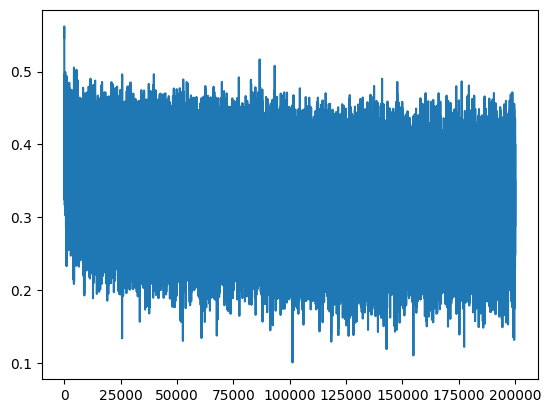

In [74]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]
    # forward pass
    # emb = C[Xb] # embed the characters into vectors
    # x = emb.view(emb.shape[0], -1) # flatten the batch of embeddings
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data -= lr * p.grad
    # exponential moving average of the loss
    lossi.append(loss.log10().item())

    # track stats
    if i % 1000 == 0:
        print(f"{i:7d}/{max_steps:7d} {loss.item():.4f}")

# plot the loss
plt.plot(lossi)
        

In [75]:
# put layers into eval mode (needed for batchnorm especially)
for layer in model.layers:
    layer.training = False

In [77]:
# sample from the model
for _ in range(20):
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
        logits = model(torch.tensor([context]))
        probs = F.softmax(logits, dim=-1)
        # print(probs)
        ix = torch.multinomial(probs, num_samples=1).item()
        context = context[1:] + [ix]
        out.append(itos[ix])
        if ix == 0:
            break
    print("".join(out))


tyr.
kwyle.
cadasia.
mick.
dailyna.
jei.
ston.
dwswe.
guhlin.
kaher.
all.
zen.
elji.
elo.
shauna.
mali.
gan.
ara.
kjesen.
corlesia.


# Step 4 Create WaveNet

In [78]:
block_size = 8 # context length: how many characters do we take to predict the next one
# build the dataset
def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])  # 80%
Xdev, Ydev = build_dataset(words[n1:n2])  # 10%
Xte, Yte = build_dataset(words[n2:])  # 10%

In [79]:
for x,y in zip(Xtr[:20], Ytr[:20]):
    print("".join(itos[i.item()] for i in x), "->", itos[y.item()])

........ -> e
.......e -> b
......eb -> r
.....ebr -> i
....ebri -> m
...ebrim -> a
..ebrima -> .
........ -> h
.......h -> i
......hi -> l
.....hil -> t
....hilt -> o
...hilto -> n
..hilton -> .
........ -> j
.......j -> h
......jh -> e
.....jhe -> n
....jhen -> e
...jhene -> .


In [80]:
n_embd = 10 # the dimension of the embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of MLP

# C = torch.randn((vocab_size, n_embd))
model = Sequential([
    Embedding(vocab_size, n_embd),
    Flatten(),
    Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size)
])

# parameters init
with torch.no_grad():
    layers[-1].weight *= 0.1 # last year make less confident

parameters = model.parameters()
print(sum(p.numel() for p in parameters)) # number of parameters in total
for p in parameters:
    p.requires_grad = True


22097


In [81]:
ix = torch.randint(0, Xtr.shape[0], (4,)) # let's look at a batch of just 4 examples
Xb, Yb = Xtr[ix], Ytr[ix]
logits = model(Xb)
print(Xb.shape)
Xb


torch.Size([4, 8])


tensor([[ 0,  0,  0,  0,  0,  0, 20, 25],
        [ 0,  0,  8,  1, 18, 12, 25, 14],
        [ 4,  1, 18, 12,  5, 14, 25, 19],
        [ 0,  0,  0,  0,  0,  0,  0,  0]])

In [83]:
model.layers[0].out.shape

AttributeError: 'Embedding' object has no attribute 'out'